## Importing the libraries

In [76]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import tensorflow as tf
import warnings
warnings.filterwarnings('ignore')

## Load and Prepare Data

In [2]:
df1=pd.read_csv('country_vaccinations.csv')
df2=pd.read_csv('country_vaccinations_by_manufacturer.csv')

## EDA

In [3]:
df1.shape

(31240, 15)

In [4]:
df2.shape

(9157, 4)

In [5]:
df1.head(10)

,country,iso_code,date,total_vaccinations,people_vaccinated,people_fully_vaccinated,daily_vaccinations_raw,daily_vaccinations,total_vaccinations_per_hundred,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,daily_vaccinations_per_million,vaccines,source_name,source_website
0,Afghanistan,AFG,2021-02-22,0.0,0.0,NaN,NaN,NaN,0.00,0.00,NaN,NaN,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
1,Afghanistan,AFG,2021-02-23,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,35.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
2,Afghanistan,AFG,2021-02-24,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,35.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
3,Afghanistan,AFG,2021-02-25,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,35.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
4,Afghanistan,AFG,2021-02-26,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,35.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
5,Afghanistan,AFG,2021-02-27,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,35.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
6,Afghanistan,AFG,2021-02-28,8200.0,8200.0,NaN,NaN,1367.0,0.02,0.02,NaN,35.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
7,Afghanistan,AFG,2021-03-01,NaN,NaN,NaN,NaN,1580.0,NaN,NaN,NaN,41.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
8,Afghanistan,AFG,2021-03-02,NaN,NaN,NaN,NaN,1794.0,NaN,NaN,NaN,46.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
9,Afghanistan,AFG,2021-03-03,NaN,NaN,NaN,NaN,2008.0,NaN,NaN,NaN,52.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/


In [6]:
df1.tail(10)

,country,iso_code,date,total_vaccinations,people_vaccinated,people_fully_vaccinated,daily_vaccinations_raw,daily_vaccinations,total_vaccinations_per_hundred,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,daily_vaccinations_per_million,vaccines,source_name,source_website
31230,Zimbabwe,ZWE,2021-07-06,1382567.0,807633.0,574934.0,13131.0,9567.0,9.30,5.43,3.87,644.0,Sinopharm/Beijing,Ministry of Health,https://twitter.com/MoHCCZim/status/1415771723...
31231,Zimbabwe,ZWE,2021-07-07,1398757.0,819058.0,579699.0,16190.0,9474.0,9.41,5.51,3.90,637.0,Sinopharm/Beijing,Ministry of Health,https://twitter.com/MoHCCZim/status/1415771723...
31232,Zimbabwe,ZWE,2021-07-08,1433578.0,848808.0,584770.0,34821.0,13088.0,9.65,5.71,3.93,881.0,Sinopharm/Beijing,Ministry of Health,https://twitter.com/MoHCCZim/status/1415771723...
31233,Zimbabwe,ZWE,2021-07-09,1464065.0,875182.0,588883.0,30487.0,15907.0,9.85,5.89,3.96,1070.0,Sinopharm/Beijing,Ministry of Health,https://twitter.com/MoHCCZim/status/1415771723...
31234,Zimbabwe,ZWE,2021-07-10,NaN,NaN,NaN,NaN,16878.0,NaN,NaN,NaN,1136.0,Sinopharm/Beijing,Ministry of Health,https://twitter.com/MoHCCZim/status/1415771723...
31235,Zimbabwe,ZWE,2021-07-11,1491397.0,895980.0,595417.0,NaN,18598.0,10.03,6.03,4.01,1251.0,Sinopharm/Beijing,Ministry of Health,https://twitter.com/MoHCCZim/status/1415771723...
31236,Zimbabwe,ZWE,2021-07-12,1531868.0,926312.0,605556.0,40471.0,23205.0,10.31,6.23,4.07,1561.0,Sinopharm/Beijing,Ministry of Health,https://twitter.com/MoHCCZim/status/1415771723...
31237,Zimbabwe,ZWE,2021-07-13,1575539.0,955656.0,619883.0,43671.0,27567.0,10.60,6.43,4.17,1855.0,Sinopharm/Beijing,Ministry of Health,https://twitter.com/MoHCCZim/status/1415771723...
31238,Zimbabwe,ZWE,2021-07-14,1613640.0,988746.0,624894.0,38101.0,30698.0,10.86,6.65,4.20,2065.0,Sinopharm/Beijing,Ministry of Health,https://twitter.com/MoHCCZim/status/1415771723...
31239,Zimbabwe,ZWE,2021-07-15,1666862.0,1036252.0,630610.0,53222.0,33326.0,11.21,6.97,4.24,2242.0,Sinopharm/Beijing,Ministry of Health,https://twitter.com/MoHCCZim/status/1415771723...


In [7]:
df2.head(10)

,location,date,vaccine,total_vaccinations
0,Austria,2021-01-08,Johnson&Johnson,0
1,Austria,2021-01-08,Moderna,0
2,Austria,2021-01-08,Oxford/AstraZeneca,0
3,Austria,2021-01-08,Pfizer/BioNTech,30974
4,Austria,2021-01-15,Johnson&Johnson,0
5,Austria,2021-01-15,Moderna,88
6,Austria,2021-01-15,Oxford/AstraZeneca,0
7,Austria,2021-01-15,Pfizer/BioNTech,115540
8,Austria,2021-01-22,Johnson&Johnson,0
9,Austria,2021-01-22,Moderna,300


so we want to train a model in order to estimate number of vaccinated people 

In [8]:
df1.columns

Index(['country', 'iso_code', 'date', 'total_vaccinations',
       'people_vaccinated', 'people_fully_vaccinated',
       'daily_vaccinations_raw', 'daily_vaccinations',
       'total_vaccinations_per_hundred', 'people_vaccinated_per_hundred',
       'people_fully_vaccinated_per_hundred', 'daily_vaccinations_per_million',
       'vaccines', 'source_name', 'source_website'],
      dtype='object')

In [9]:
df2.columns

Index(['location', 'date', 'vaccine', 'total_vaccinations'], dtype='object')

In [10]:
df1.dtypes

country                                 object
iso_code                                object
date                                    object
total_vaccinations                     float64
people_vaccinated                      float64
people_fully_vaccinated                float64
daily_vaccinations_raw                 float64
daily_vaccinations                     float64
total_vaccinations_per_hundred         float64
people_vaccinated_per_hundred          float64
people_fully_vaccinated_per_hundred    float64
daily_vaccinations_per_million         float64
vaccines                                object
source_name                             object
source_website                          object
dtype: object

In [11]:
df2.dtypes

location              object
date                  object
vaccine               object
total_vaccinations     int64
dtype: object

In [12]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31240 entries, 0 to 31239
Data columns (total 15 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   country                              31240 non-null  object 
 1   iso_code                             31240 non-null  object 
 2   date                                 31240 non-null  object 
 3   total_vaccinations                   17451 non-null  float64
 4   people_vaccinated                    16554 non-null  float64
 5   people_fully_vaccinated              13795 non-null  float64
 6   daily_vaccinations_raw               14421 non-null  float64
 7   daily_vaccinations                   30948 non-null  float64
 8   total_vaccinations_per_hundred       17451 non-null  float64
 9   people_vaccinated_per_hundred        16554 non-null  float64
 10  people_fully_vaccinated_per_hundred  13795 non-null  float64
 11  daily_vaccinations_per_milli

In [13]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9157 entries, 0 to 9156
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   location            9157 non-null   object
 1   date                9157 non-null   object
 2   vaccine             9157 non-null   object
 3   total_vaccinations  9157 non-null   int64 
dtypes: int64(1), object(3)
memory usage: 286.3+ KB


lets chech how many NA do we have

In [14]:
df1.isnull().sum()

country                                    0
iso_code                                   0
date                                       0
total_vaccinations                     13789
people_vaccinated                      14686
people_fully_vaccinated                17445
daily_vaccinations_raw                 16819
daily_vaccinations                       292
total_vaccinations_per_hundred         13789
people_vaccinated_per_hundred          14686
people_fully_vaccinated_per_hundred    17445
daily_vaccinations_per_million           292
vaccines                                   0
source_name                                0
source_website                             0
dtype: int64

In [15]:
df2.isnull().sum()

location              0
date                  0
vaccine               0
total_vaccinations    0
dtype: int64

we have so many NA. we have to handle them

In [16]:
df1.describe()

,total_vaccinations,people_vaccinated,people_fully_vaccinated,daily_vaccinations_raw,daily_vaccinations,total_vaccinations_per_hundred,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,daily_vaccinations_per_million
count,1.745100e+04,1.655400e+04,1.379500e+04,1.442100e+04,3.094800e+04,17451.000000,16554.000000,13795.000000,30948.000000
mean,1.200444e+07,5.704551e+06,3.293973e+06,2.273661e+05,1.149718e+05,29.283554,19.181574,12.340698,3426.365969
std,6.622349e+07,2.101612e+07,1.234425e+07,1.258556e+06,8.460548e+05,35.042304,20.734193,15.857682,4572.377684
min,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,1.262015e+05,9.999100e+04,4.832450e+04,4.324000e+03,8.520000e+02,2.970000,2.580000,1.320000,412.000000
50%,8.890780e+05,6.450395e+05,3.632100e+05,2.133600e+04,6.471000e+03,14.510000,10.730000,5.560000,1851.000000
75%,4.213660e+06,2.809300e+06,1.635366e+06,9.441700e+04,3.545425e+04,44.460000,30.890000,17.610000,5123.000000
max,1.426347e+09,6.220000e+08,2.232990e+08,2.474100e+07,2.242429e+07,232.350000,116.660000,115.690000,118759.000000


In [17]:
df2.describe()

,total_vaccinations
count,9.157000e+03
mean,6.024868e+06
std,2.115246e+07
min,0.000000e+00
25%,4.064400e+04
50%,3.388750e+05
75%,2.293498e+06
max,1.865092e+08


we need to scale our data too

In [18]:
df1.duplicated().sum()

np.int64(0)

In [19]:
df2.duplicated().sum()

np.int64(0)

so we dont have duplicated data

before taking any other steps we need to understand how our columns are

In [20]:
df1['country'].unique()

array(['Afghanistan', 'Albania', 'Algeria', 'Andorra', 'Angola',
       'Anguilla', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Aruba',
       'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain',
       'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin',
       'Bermuda', 'Bhutan', 'Bolivia', 'Bonaire Sint Eustatius and Saba',
       'Bosnia and Herzegovina', 'Botswana', 'Brazil',
       'British Virgin Islands', 'Brunei', 'Bulgaria', 'Burkina Faso',
       'Cambodia', 'Cameroon', 'Canada', 'Cape Verde', 'Cayman Islands',
       'Central African Republic', 'Chad', 'Chile', 'China', 'Colombia',
       'Comoros', 'Congo', 'Cook Islands', 'Costa Rica', "Cote d'Ivoire",
       'Croatia', 'Cuba', 'Curacao', 'Cyprus', 'Czechia',
       'Democratic Republic of Congo', 'Denmark', 'Djibouti', 'Dominica',
       'Dominican Republic', 'Ecuador', 'Egypt', 'El Salvador', 'England',
       'Equatorial Guinea', 'Estonia', 'Eswatini', 'Ethiopia',
       'Faeroe Islands', 'Fal

In [21]:
df2['location'].unique()

array(['Austria', 'Belgium', 'Bulgaria', 'Chile', 'Croatia', 'Cyprus',
       'Czechia', 'Denmark', 'Estonia', 'Finland', 'France', 'Germany',
       'Hungary', 'Iceland', 'Ireland', 'Italy', 'Japan', 'Latvia',
       'Liechtenstein', 'Lithuania', 'Luxembourg', 'Malta', 'Netherlands',
       'Poland', 'Portugal', 'Romania', 'Slovakia', 'Slovenia', 'Spain',
       'Sweden', 'Switzerland', 'United States', 'Uruguay'], dtype=object)

we choose austria for our project

## Data Preprocessing

In [22]:
X = df1.loc[df1['country']=='Austria']
Y = df2.loc[df2['location']=='Austria']

In [23]:
X.shape

(201, 15)

In [24]:
Y.shape

(112, 4)

In [25]:
X.head(5)

,country,iso_code,date,total_vaccinations,people_vaccinated,people_fully_vaccinated,daily_vaccinations_raw,daily_vaccinations,total_vaccinations_per_hundred,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,daily_vaccinations_per_million,vaccines,source_name,source_website
1616,Austria,AUT,2020-12-27,747.0,747.0,NaN,NaN,NaN,0.01,0.01,NaN,NaN,"Johnson&Johnson, Moderna, Oxford/AstraZeneca, ...",Ministry of Health,https://info.gesundheitsministerium.gv.at/open...
1617,Austria,AUT,2020-12-28,2065.0,2064.0,1.0,1318.0,1318.0,0.02,0.02,0.0,146.0,"Johnson&Johnson, Moderna, Oxford/AstraZeneca, ...",Ministry of Health,https://info.gesundheitsministerium.gv.at/open...
1618,Austria,AUT,2020-12-29,3695.0,3694.0,1.0,1630.0,1474.0,0.04,0.04,0.0,164.0,"Johnson&Johnson, Moderna, Oxford/AstraZeneca, ...",Ministry of Health,https://info.gesundheitsministerium.gv.at/open...
1619,Austria,AUT,2020-12-30,5062.0,5061.0,1.0,1367.0,1438.0,0.06,0.06,0.0,160.0,"Johnson&Johnson, Moderna, Oxford/AstraZeneca, ...",Ministry of Health,https://info.gesundheitsministerium.gv.at/open...
1620,Austria,AUT,2020-12-31,5073.0,5072.0,1.0,11.0,1082.0,0.06,0.06,0.0,120.0,"Johnson&Johnson, Moderna, Oxford/AstraZeneca, ...",Ministry of Health,https://info.gesundheitsministerium.gv.at/open...


In [26]:
Y.head(5)

,location,date,vaccine,total_vaccinations
0,Austria,2021-01-08,Johnson&Johnson,0
1,Austria,2021-01-08,Moderna,0
2,Austria,2021-01-08,Oxford/AstraZeneca,0
3,Austria,2021-01-08,Pfizer/BioNTech,30974
4,Austria,2021-01-15,Johnson&Johnson,0


In [27]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 201 entries, 1616 to 1816
Data columns (total 15 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   country                              201 non-null    object 
 1   iso_code                             201 non-null    object 
 2   date                                 201 non-null    object 
 3   total_vaccinations                   201 non-null    float64
 4   people_vaccinated                    201 non-null    float64
 5   people_fully_vaccinated              200 non-null    float64
 6   daily_vaccinations_raw               200 non-null    float64
 7   daily_vaccinations                   200 non-null    float64
 8   total_vaccinations_per_hundred       201 non-null    float64
 9   people_vaccinated_per_hundred        201 non-null    float64
 10  people_fully_vaccinated_per_hundred  200 non-null    float64
 11  daily_vaccinations_per_million   

In [28]:
X['vaccines'].unique()

array(['Johnson&Johnson, Moderna, Oxford/AstraZeneca, Pfizer/BioNTech'],
      dtype=object)

In [29]:
Y['vaccine'].unique()

array(['Johnson&Johnson', 'Moderna', 'Oxford/AstraZeneca',
       'Pfizer/BioNTech'], dtype=object)

we drop columns which dont have any role in our model. in test dataset we only have 3 columns: date,vaccines,total number so
we have to delete other columns. unfortunately vaccine columns in X dataset is general so it cant be used

In [30]:
X_new=X[['total_vaccinations']]
Y_new=Y.drop(['date','vaccine'],axis=1)

we create new date type columns

In [31]:
X['date'] = pd.to_datetime(X['date'])
X_new['year'] = X['date'].dt.year
X_new['month'] = X['date'].dt.month
X_new['day'] = X['date'].dt.day
Y['date'] = pd.to_datetime(Y['date'])
Y_new['year'] = Y['date'].dt.year
Y_new['month'] = Y['date'].dt.month
Y_new['day'] = Y['date'].dt.day

In [32]:
first_col = X_new.pop(X_new.columns[0])
X_new[first_col.name] = first_col
X_new.head(10)

,year,month,day,total_vaccinations
1616,2020,12,27,747.0
1617,2020,12,28,2065.0
1618,2020,12,29,3695.0
1619,2020,12,30,5062.0
1620,2020,12,31,5073.0
1621,2021,1,1,5080.0
1622,2021,1,2,5088.0
1623,2021,1,3,5094.0
1624,2021,1,4,5217.0
1625,2021,1,5,7024.0


In [33]:
Y_new.head()

,location,total_vaccinations,year,month,day
0,Austria,0,2021,1,8
1,Austria,0,2021,1,8
2,Austria,0,2021,1,8
3,Austria,30974,2021,1,8
4,Austria,0,2021,1,15


In [34]:
X_new.isnull().sum()

year                  0
month                 0
day                   0
total_vaccinations    0
dtype: int64

we dont need to hande NA 

In [35]:
X_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 201 entries, 1616 to 1816
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   year                201 non-null    int32  
 1   month               201 non-null    int32  
 2   day                 201 non-null    int32  
 3   total_vaccinations  201 non-null    float64
dtypes: float64(1), int32(3)
memory usage: 5.5 KB


as you can see in Y data set based on vaccine type they have split the number so we need to use a summation in this case

In [36]:
Y_new = Y_new.groupby(['year', 'month', 'day'], as_index=False).agg({
    'total_vaccinations': 'sum'
})

In [37]:
Y_new.head()

,year,month,day,total_vaccinations
0,2021,1,8,30974
1,2021,1,15,115628
2,2021,1,22,213163
3,2021,1,29,261665
4,2021,2,5,358699


scalling the data

## Strorytelling - Visualization

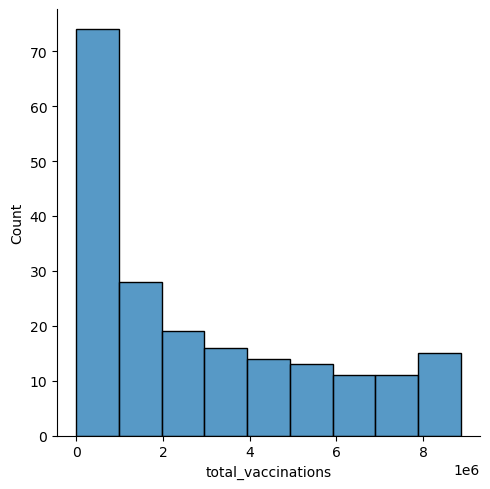

In [38]:
sns.displot(X_new,x='total_vaccinations',shrink=1)

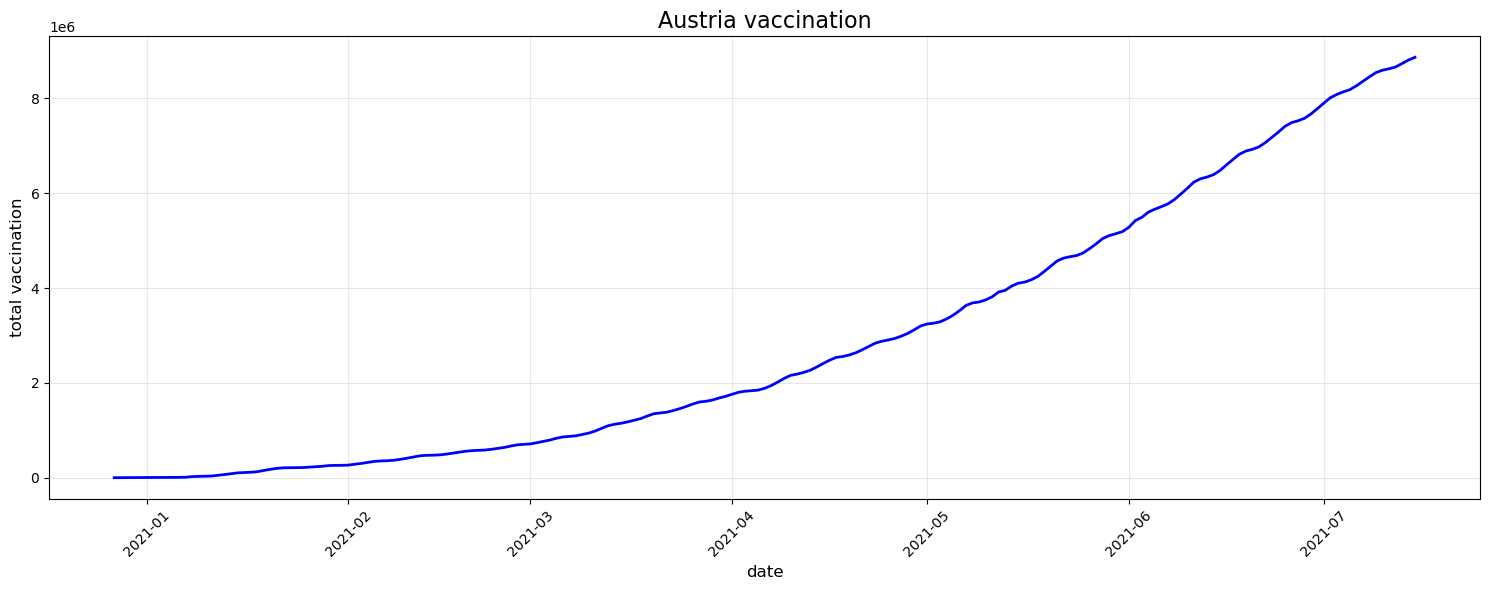

In [39]:
plt.figure(figsize=(15, 6))
plt.plot(X['date'], X_new['total_vaccinations'], linewidth=2, color='blue')
plt.title('Austria vaccination', fontsize=16)
plt.xlabel('date', fontsize=12)
plt.ylabel('total vaccination', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

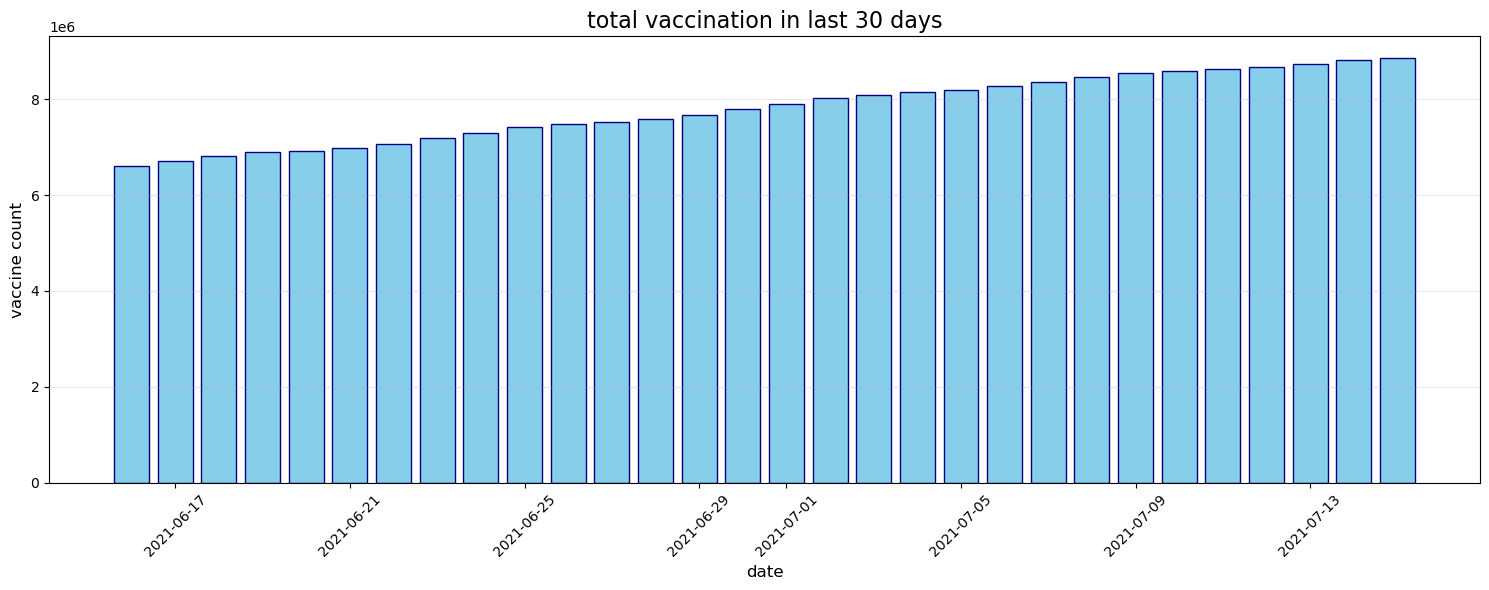

In [40]:
df_last_30 = X.tail(30)
plt.figure(figsize=(15, 6))
plt.bar(df_last_30['date'], df_last_30['total_vaccinations'], color='skyblue', edgecolor='navy')
plt.title('total vaccination in last 30 days', fontsize=16)
plt.xlabel('date', fontsize=12)
plt.ylabel('vaccine count', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

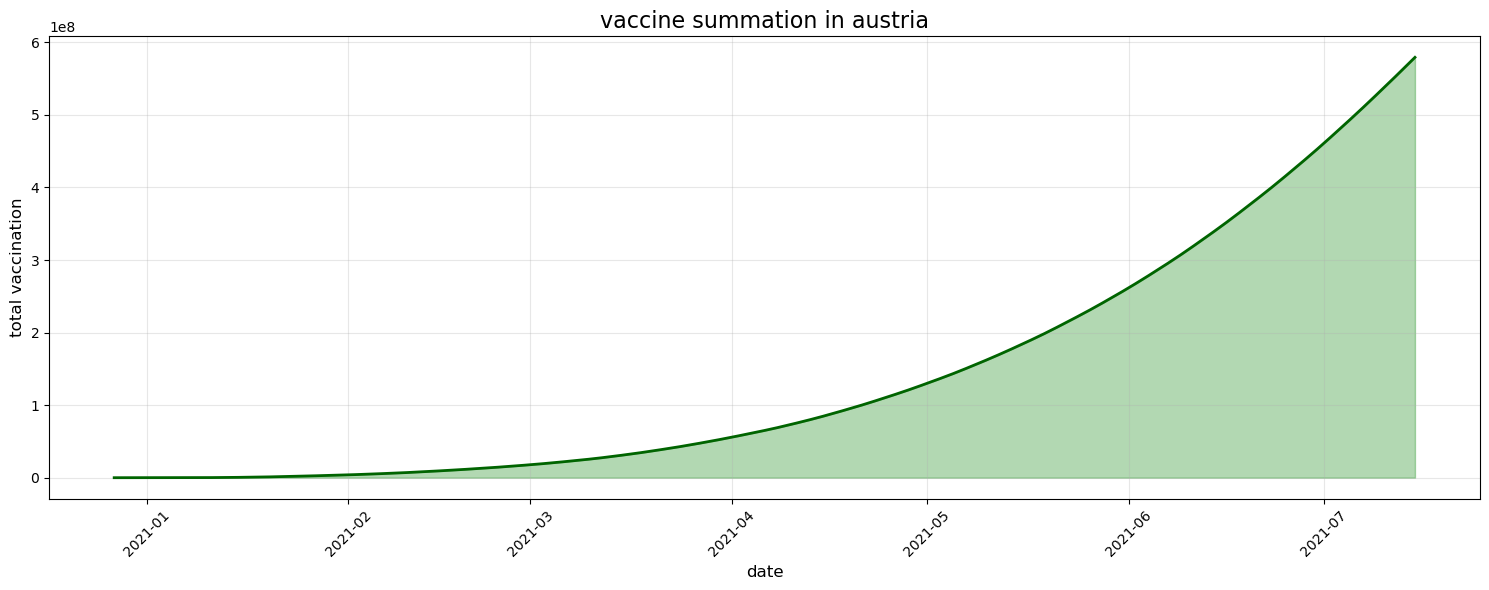

In [41]:
X['cumulative'] = X['total_vaccinations'].cumsum()
plt.figure(figsize=(15, 6))
plt.fill_between(X['date'], 0, X['cumulative'], alpha=0.3, color='green')
plt.plot(X['date'], X['cumulative'], linewidth=2, color='darkgreen')
plt.title('vaccine summation in austria', fontsize=16)
plt.xlabel('date', fontsize=12)
plt.ylabel('total vaccination', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

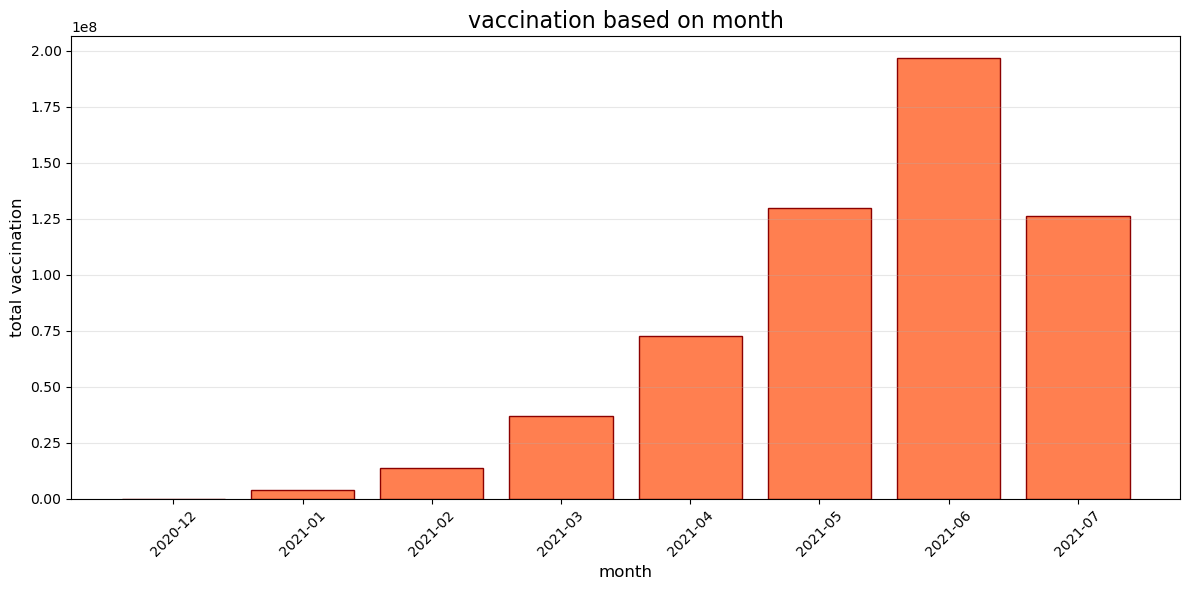

In [42]:
monthly_data = X_new.groupby(['year', 'month'])['total_vaccinations'].sum().reset_index()
monthly_data['month_name'] = pd.to_datetime(monthly_data[['year', 'month']].assign(day=1)).dt.strftime('%Y-%m')

plt.figure(figsize=(12, 6))
plt.bar(monthly_data['month_name'], monthly_data['total_vaccinations'], 
        color='coral', edgecolor='darkred')
plt.title('vaccination based on month', fontsize=16)
plt.xlabel('month', fontsize=12)
plt.ylabel('total vaccination', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [43]:
corr=X_new.corr()
corr.shape

(4, 4)

<Axes: >

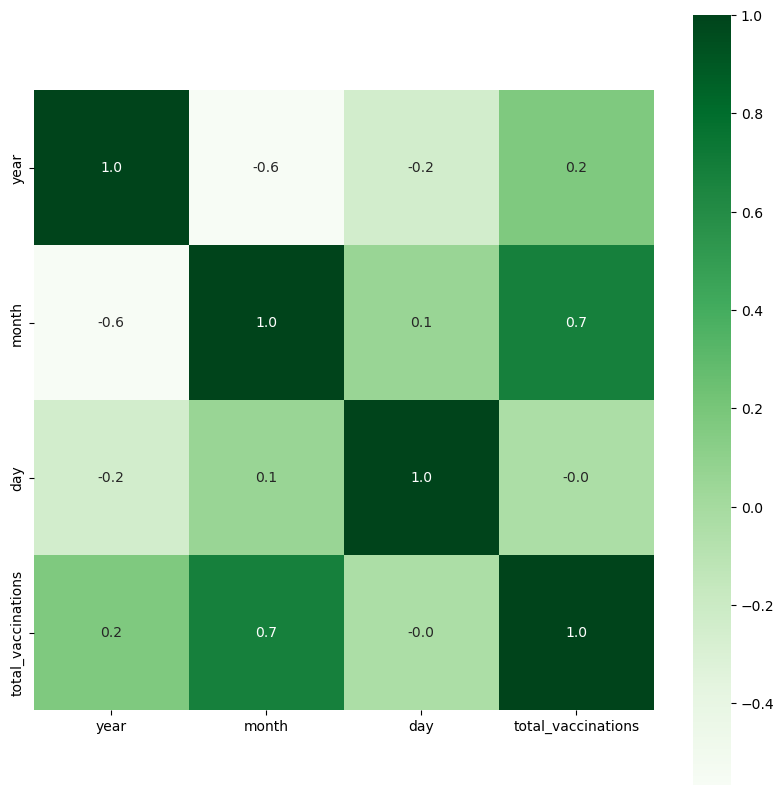

In [44]:
plt.figure(figsize=(10,10))
sns.heatmap(corr,cbar=True,square=True,fmt='.1f',annot=True,cmap='Greens')

## Prepare Data for Machine learning

In [45]:
sc = StandardScaler()
X_model=sc.fit_transform(X_new)
Y_model=sc.transform(Y_new)
X_model=pd.DataFrame(X_model)
Y_model=pd.DataFrame(Y_model)

## Train your model

first i use linear regression

In [55]:
SLR=LinearRegression()
SLR.fit(X_model.iloc[:,[1]], X_model.iloc[:,-1])
Y_prediction_SLR=SLR.predict(Y_model.iloc[:,[1]])

In [86]:
print("MAE is:",sklearn.metrics.mean_absolute_error(Y_model.iloc[:,-1],Y_prediction_SLR))
print("MSE is:",sklearn.metrics.mean_squared_error(Y_model.iloc[:,-1],Y_prediction_SLR))
print("RMSE is:",np.sqrt(sklearn.metrics.mean_squared_error(Y_model.iloc[:,-1],Y_prediction_SLR)))
print("R^2 is:",sklearn.metrics.r2_score(Y_prediction_SLR,Y_model.iloc[:,-1]))
RSLR=sklearn.metrics.r2_score(Y_prediction_SLR,Y_model.iloc[:,-1])

MAE is: 0.396596662960412
MSE is: 0.27946829366758646
RMSE is: 0.5286476082113551
R^2 is: 0.15114378575998866


this model is not good at all lets improve it

In [49]:
MLR=LinearRegression()
MLR.fit(X_model.iloc[:,:-1], X_model.iloc[:,-1])
Y_prediction_MLR=MLR.predict(Y_model.iloc[:,:-1])

In [87]:
print("MAE is:",sklearn.metrics.mean_absolute_error(Y_model.iloc[:,-1],Y_prediction_MLR))
print("MSE is:",sklearn.metrics.mean_squared_error(Y_model.iloc[:,-1],Y_prediction_MLR))
print("RMSE is:",np.sqrt(sklearn.metrics.mean_squared_error(Y_model.iloc[:,-1],Y_prediction_MLR)))
print("R^2 is:",sklearn.metrics.r2_score(Y_prediction_MLR,Y_model.iloc[:,-1]))
RMLR=sklearn.metrics.r2_score(Y_prediction_MLR,Y_model.iloc[:,-1])

MAE is: 0.23616122583036817
MSE is: 0.07509286616079328
RMSE is: 0.2740307759372901
R^2 is: 0.9180839080193749


now i use polynomial one too

In [59]:
poly_features=PolynomialFeatures(degree=2)
X_train_quadratic=poly_features.fit_transform(X_model.iloc[:,:-1])
PLR=LinearRegression()
PLR.fit(X_train_quadratic,X_model.iloc[:,-1])
X_test_quadratic=poly_features.transform(Y_model.iloc[:,:-1])
Y_prediction_PLR=PLR.predict(X_test_quadratic)

In [88]:
print("MAE is:",sklearn.metrics.mean_absolute_error(Y_model.iloc[:,-1],Y_prediction_PLR))
print("MSE is:",sklearn.metrics.mean_squared_error(Y_model.iloc[:,-1],Y_prediction_PLR))
print("RMSE is:",np.sqrt(sklearn.metrics.mean_squared_error(Y_model.iloc[:,-1],Y_prediction_PLR)))
print("R^2 is:",sklearn.metrics.r2_score(Y_prediction_PLR,Y_model.iloc[:,-1]))
RPLR=sklearn.metrics.r2_score(Y_prediction_PLR,Y_model.iloc[:,-1])

MAE is: 0.03506250391244294
MSE is: 0.0017888349941016064
RMSE is: 0.04229462133772575
R^2 is: 0.998318874186076


as we can see the R^2 score show a really good model

just for educational purpose i use other models too

In [70]:
SVR_RBF=SVR(kernel='rbf',C=1e4,gamma=0.1)
SVR_LIN=SVR(kernel='linear',C=1e4)
SVR_POLY=SVR(kernel='poly',C=1e4,degree=3)

first we use SVR in rbf kernel

In [64]:
Y_prediction_RBF=SVR_RBF.fit(X_model.iloc[:,:-1],X_model.iloc[:,-1]).predict(Y_model.iloc[:,:-1])

In [89]:
print("MAE is:",sklearn.metrics.mean_absolute_error(Y_model.iloc[:,-1],Y_prediction_RBF))
print("MSE is:",sklearn.metrics.mean_squared_error(Y_model.iloc[:,-1],Y_prediction_RBF))
print("RMSE is:",np.sqrt(sklearn.metrics.mean_squared_error(Y_model.iloc[:,-1],Y_prediction_RBF)))
print("R^2 is:",sklearn.metrics.r2_score(Y_prediction_RBF,Y_model.iloc[:,-1]))
RRBF=sklearn.metrics.r2_score(Y_prediction_RBF,Y_model.iloc[:,-1])

MAE is: 0.0489634370918322
MSE is: 0.003511852775566411
RMSE is: 0.05926088740110471
R^2 is: 0.9966601511422617


second we use linear kernel

In [66]:
Y_prediction_LIN=SVR_LIN.fit(X_model.iloc[:,:-1],X_model.iloc[:,-1]).predict(Y_model.iloc[:,:-1])

In [90]:
print("MAE is:",sklearn.metrics.mean_absolute_error(Y_model.iloc[:,-1],Y_prediction_LIN))
print("MSE is:",sklearn.metrics.mean_squared_error(Y_model.iloc[:,-1],Y_prediction_LIN))
print("RMSE is:",np.sqrt(sklearn.metrics.mean_squared_error(Y_model.iloc[:,-1],Y_prediction_LIN)))
print("R^2 is:",sklearn.metrics.r2_score(Y_prediction_LIN,Y_model.iloc[:,-1]))
RLIN=sklearn.metrics.r2_score(Y_prediction_LIN,Y_model.iloc[:,-1])

MAE is: 0.24400343738549155
MSE is: 0.08871510344452681
RMSE is: 0.2978508073591992
R^2 is: 0.8989272146489367


and for the last one we use polynomial

In [71]:
Y_prediction_POLY=SVR_POLY.fit(X_model.iloc[:,:-1],X_model.iloc[:,-1]).predict(Y_model.iloc[:,:-1])

In [91]:
print("MAE is:",sklearn.metrics.mean_absolute_error(Y_model.iloc[:,-1],Y_prediction_POLY))
print("MSE is:",sklearn.metrics.mean_squared_error(Y_model.iloc[:,-1],Y_prediction_POLY))
print("RMSE is:",np.sqrt(sklearn.metrics.mean_squared_error(Y_model.iloc[:,-1],Y_prediction_POLY)))
print("R^2 is:",sklearn.metrics.r2_score(Y_prediction_POLY,Y_model.iloc[:,-1]))
RPOLY=sklearn.metrics.r2_score(Y_prediction_POLY,Y_model.iloc[:,-1])

MAE is: 0.06910358837426357
MSE is: 0.006088750153769794
RMSE is: 0.07803044376248154
R^2 is: 0.9941992203122562


I want to use decision tree in this example too

In [74]:
DTR=DecisionTreeRegressor(random_state=0)
Y_prediction_DTR=DTR.fit(X_model.iloc[:,:-1],X_model.iloc[:,-1]).predict(Y_model.iloc[:,:-1])

In [92]:
print("MAE is:",sklearn.metrics.mean_absolute_error(Y_model.iloc[:,-1],Y_prediction_DTR))
print("MSE is:",sklearn.metrics.mean_squared_error(Y_model.iloc[:,-1],Y_prediction_DTR))
print("RMSE is:",np.sqrt(sklearn.metrics.mean_squared_error(Y_model.iloc[:,-1],Y_prediction_DTR)))
print("R^2 is:",sklearn.metrics.r2_score(Y_prediction_DTR,Y_model.iloc[:,-1]))
RDTR=sklearn.metrics.r2_score(Y_prediction_DTR,Y_model.iloc[:,-1])

MAE is: 0.01745541753356198
MSE is: 0.0004212082480659565
RMSE is: 0.020523358596144944
R^2 is: 0.9996048465676778


now that we got a perfect model lets just use random forest too

In [83]:
RFR=RandomForestRegressor(n_estimators=50,random_state=40)
Y_prediction_RFR=RFR.fit(X_model.iloc[:,:-1],X_model.iloc[:,-1]).predict(Y_model.iloc[:,:-1])

In [93]:
print("MAE is:",sklearn.metrics.mean_absolute_error(Y_model.iloc[:,-1],Y_prediction_RFR))
print("MSE is:",sklearn.metrics.mean_squared_error(Y_model.iloc[:,-1],Y_prediction_RFR))
print("RMSE is:",np.sqrt(sklearn.metrics.mean_squared_error(Y_model.iloc[:,-1],Y_prediction_RFR)))
print("R^2 is:",sklearn.metrics.r2_score(Y_prediction_RFR,Y_model.iloc[:,-1]))
RRFR=sklearn.metrics.r2_score(Y_prediction_RFR,Y_model.iloc[:,-1])

MAE is: 0.020322792069825096
MSE is: 0.0005986802978874238
RMSE is: 0.024467944292224954
R^2 is: 0.9994368283249739


## Test the model and show the metrics

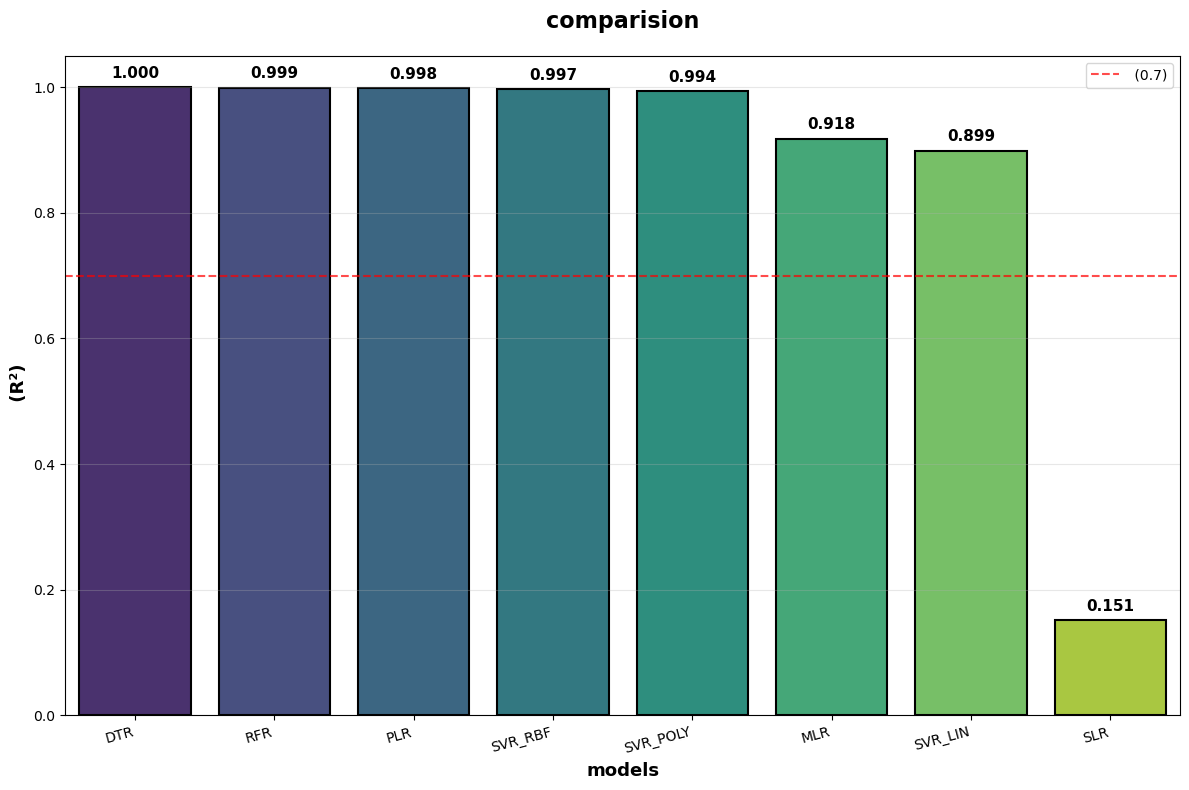

In [95]:
d = {
    'Methods': ['SLR', 'MLR', 'PLR', 'SVR_RBF', 'SVR_LIN', 'SVR_POLY', 'DTR', 'RFR'],
    'R2_Score': [RSLR, RMLR, RPLR, RRBF, RLIN, RPOLY, RDTR, RRFR]
}

dfc = pd.DataFrame(d)
dfc = dfc.sort_values('R2_Score', ascending=False)
plt.figure(figsize=(12, 8))
ax = sns.barplot(
    x='Methods', 
    y='R2_Score',  
    data=dfc,
    palette='viridis', 
    edgecolor='black',
    linewidth=1.5
)

for i, v in enumerate(dfc['R2_Score']):
    ax.text(i, v + 0.01, f'{v:.3f}', 
            ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.title('comparision', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('models', fontsize=13, fontweight='bold')
plt.ylabel(' (R²)', fontsize=13, fontweight='bold')
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=15, ha='right')
plt.axhline(y=0.7, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label=' (0.7)')
plt.legend()

plt.tight_layout()
plt.show()